In [1]:
# Install the frameworks if they're not already available (safe to re-run).
!pip install snntorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 8.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import spikeplot as splt
from snntorch import utils

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Reproducibility + device
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

Using device: cpu


# Load the data
We use the MNIST dataset, which consists of 28x28 pixel grayscale images.

In [4]:
# dataloader arguments
batch_size = 128
data_path = "/tmp/data/mnist"

# scale pixel intensities to [0, 1].
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,)),
])

mnist_train = datasets.MNIST(data_path, train=True,  download=True, transform=transform)
mnist_test  = datasets.MNIST(data_path, train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True,  drop_last=True)
test_loader  = DataLoader(mnist_test,  batch_size=batch_size, shuffle=True,  drop_last=True)

print("Train samples:", len(mnist_train), "| Test samples:", len(mnist_test))

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 12.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 105MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


Train samples: 60000 | Test samples: 10000


# Prepare the functions
We use rate-coded spikes. Each pixel intensity (normalized between [0,1] is mapped to a firing rate. Every timestep, we draw a spike with a probability proportional to that rate (Bernoulli sampling). Brighter pixels fire more often over the T timesteps.

In [5]:
def encode_rate(x, rmin, rmax, T):
    """Convert pixel intensities in [0, 1] into a rate-coded spike train.

    Higher intensity pixels produce a higher firing rate (more spikes).
    Returns a boolean tensor of shape [T, num_pixels].
    """
    x = torch.as_tensor(x, dtype=torch.float32)

    # Map intensity -> firing rate (in Hz), between rmin and rmax
    rates = rmin + (rmax - rmin) * x

    # Per-timestep spike probability (assuming a 1 ms bin -> divide Hz by 1000)
    p = torch.clamp(rates / 1000.0, min=0.0, max=1.0)

    # Bernoulli sampling: one draw per (timestep, pixel)
    spikes = torch.rand(T, x.numel()) < p.unsqueeze(0)
    return spikes

# Rate-coding parameters
rmin = 0     # Hz for a black pixel
rmax = 50    # Hz for a white pixel
T    = 400   # number of timesteps

The official `snntorch.Leaky()` does not allow for intrinsic plasticity. We extend the forward function to allow updating the firing threshold based on the firing rate.

- With `self.rate = spk.float().mean(dim=0)` we can compute the firing rate individually for each neuron in the layer. We average only over all batch input samples. Hence, the firing threshold can differ between neurons of a layer.

- With `self.rate = spk.float().mean()` we average the firing rate over all batch input samples and neurons. Hence, the firing threshold is identical for all neurons in the layer.

NOTE: Currently, we only consider the current firing rate, which can differ drastically between steps. We could also consider the previous firing rate for smoother transitions, e.g. the exponential moving average `self.rate = 0.99 * self.rate + 0.01 * spk.float().mean()`.

In [6]:
class LeakyHIP(snn.Leaky):
    def __init__(self, *args, eta=0.02, target_rate=0.2, **kwargs):
        super().__init__(*args, **kwargs)
        self.eta = eta
        self.target_rate = target_rate
        self.register_buffer("rate", torch.zeros(1))

    def forward(self, input_, mem=None):
        out = super().forward(input_, mem)

        # If init_hidden = True, only spk is returned
        if isinstance(out, torch.Tensor):
          spk = out        # whether a spike happened
          mem = self.mem   # internal membrane state
        # If both spk and mem are returned
        else:
          spk, mem = out

        # compute the average (across samples) firing rate of each neuron in the layer
        self.rate = spk.float().mean(dim=0)

        # homeostatic intrinsic plasticity update
        with torch.no_grad():
          self.threshold = self.threshold + self.eta * (self.rate - self.target_rate)
          self.threshold = np.clip(self.threshold, 0.05, 5.0)

        if self.output:
            return spk, mem
        elif self.init_hidden:
            return spk
        else:
            return spk, mem

We use surrogate gradient descent, whick keeps the Heaviside step function as activation function during the forward pass (true spike), but substitutes it with a smooth surrogate during backpropagation to make it differentiable.

In [7]:
def surrogate_derivative(spike_grad, x):
    """Return d(spike)/dx of a snnTorch surrogate, evaluated on tensor x.

    x is the membrane 'overdrive' U_OD = U - U_thr.
    """
    x = x.detach().clone().requires_grad_(True)
    out = spike_grad(x)          # Heaviside on the forward pass
    out.sum().backward()         # surrogate on the backward pass
    return x.grad

In [8]:
def build_snn(
    HIP:bool=False,
    etas:list=[0.03, 0.03],
    target_rates:list=[0.05, 0.05],
    num_inputs:int=784,
    num_hidden:int=1000,
    num_outputs:int=10,
    beta:float=0.9,
    spike_grad:snn.surrogate=surrogate.fast_sigmoid(slope=25),
    device:torch.device=None,
):
  """Build the Spiking Neural Network architecture."""
  if HIP:
    net = nn.Sequential(
        nn.Linear(num_inputs, num_hidden),
        LeakyHIP(beta=beta, init_hidden=True, spike_grad=spike_grad, eta=etas[0], target_rate=target_rates[0]),
        nn.Linear(num_hidden, num_outputs),
        LeakyHIP(beta=beta, init_hidden=True, spike_grad=spike_grad, eta=etas[1], target_rate=target_rates[1], output=True),
    ).to(device)

  else:
    net = nn.Sequential(
        nn.Linear(num_inputs, num_hidden),
        snn.Leaky(beta=beta, init_hidden=True, spike_grad=spike_grad),
        nn.Linear(num_hidden, num_outputs),
        snn.Leaky(beta=beta, init_hidden=True, spike_grad=spike_grad, output=True),
    ).to(device)

  return net

In [9]:
def forward_pass(net, spike_data):
    """Run the network over time on a pre-encoded spike train.

    spike_data: [num_steps, batch, 1, 28, 28] (from spikegen.rate)
    Returns stacked output spikes: [num_steps, batch, num_outputs]
    """
    spk_rec = []
    t_hidden_history = []
    t_output_history = []
    utils.reset(net)                       # clear membrane states of every Leaky
    for step in range(spike_data.size(0)):
        x_t = spike_data[step]
        x_t = x_t.view(x_t.size(0), -1)   # shape: [batch, 784]
        spk_out, _ = net(x_t)
        spk_rec.append(spk_out)
        # Log thresholds of hidden layer neurons
        t_hidden_history.append(net[1].threshold.clone().detach().cpu())
        # Log thresholds of output layer neurons
        t_output_history.append(net[3].threshold.clone().detach().cpu())
    return torch.stack(spk_rec)


def batch_accuracy(loader, net, num_steps):
    """Accuracy over a whole DataLoader using a rate code (spike counts)."""
    net.eval()
    total, acc = 0, 0
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            spike_data = spikegen.rate(data, num_steps=num_steps)
            spk_rec = forward_pass(net, spike_data)
            acc   += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
            total += spk_rec.size(1)
    return acc / total

In [10]:
def train_model(net, train_loader, test_loader, num_epochs:int=1, num_steps:int=25, device:torch.device=None):
  """Train the SNN."""
  loss_fn   = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, betas=(0.9, 0.999))

  loss_hist, test_acc_hist = [], []
  threshold_log_hidden, threshold_log_output = [], []
  counter = 0

  for epoch in range(num_epochs):
      for data, targets in train_loader:
          data, targets = data.to(device), targets.to(device)

          # rate-encode the images into a spike train
          spike_data = spikegen.rate(data, num_steps=num_steps)

          # run the forward pass over time
          net.train()
          spk_rec = forward_pass(net, spike_data)

          # log the resulting thresholds of Leaky neurons
          threshold_log_hidden.append(net[1].threshold.detach().cpu().clone())
          threshold_log_output.append(net[3].threshold.detach().cpu().clone())

          # compute the loss on the output spikes
          out_spk_count = spk_rec.sum(dim=0)   # sum over time
          loss_val = loss_fn(out_spk_count, targets)

          # backward pass
          optimizer.zero_grad()
          loss_val.backward()
          optimizer.step()

          loss_hist.append(loss_val.item())

          # apply the current model state to test data every 50 epochs
          if counter % 50 == 0:
              test_acc = batch_accuracy(test_loader, net, num_steps)
              test_acc_hist.append(test_acc.item())
              print(f"Iteration {counter:4d} | loss {loss_val.item():.3f} "
                    f"| test acc {test_acc * 100:.2f}%")
          counter += 1

  return loss_hist, test_acc_hist, threshold_log_hidden, threshold_log_output

# Model training

In [11]:
# Parameters that we can adjust
num_hidden = 1000                              # number of hidden neurons
spike_grad = surrogate.fast_sigmoid(slope=25)
num_steps = 25                                 # timesteps of the rate-coded input (raise for Colab GPU)
num_epochs = 1                                 # number of epochs to train

HIP = True                                     # whether to apply threshold adaptation
etas = [0.03, 0.03]                            # [eta for hidden layer, eta for output layer]
target_rates = [0.05, 0.05]                    # [target rate for hidden layer, target rate for output layer]

In [12]:
# Create the SNN
net = build_snn(
    HIP=HIP,
    etas=etas,
    target_rates=target_rates,
    num_inputs=28 * 28,                           # number of MNIST image pixels
    num_hidden=num_hidden,
    num_outputs=10,                               # number of MNIST classes
    beta=0.9,                                     # membrane decay of the LIF neuron
    spike_grad=spike_grad,
    device=device,
)

In [13]:
# Train the SNN
loss_hist, test_acc_hist, threshold_log_hidden, threshold_log_output = train_model(
    net=net,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=num_epochs,
    num_steps=num_steps,
    device=device,
)


Iteration    0 | loss 2.344 | test acc 29.61%
Iteration   50 | loss 1.056 | test acc 80.02%
Iteration  100 | loss 0.572 | test acc 86.25%
Iteration  150 | loss 0.606 | test acc 88.86%
Iteration  200 | loss 0.592 | test acc 91.36%
Iteration  250 | loss 0.495 | test acc 90.26%
Iteration  300 | loss 0.582 | test acc 92.47%
Iteration  350 | loss 0.389 | test acc 92.99%
Iteration  400 | loss 0.309 | test acc 93.84%
Iteration  450 | loss 0.365 | test acc 94.56%


Final test set accuracy: 94.40%


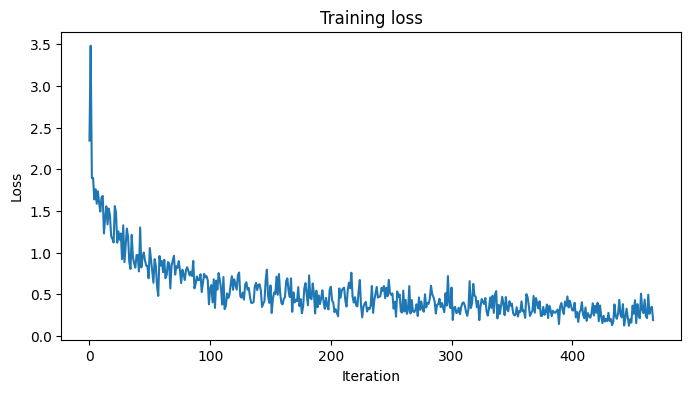

In [14]:
# Final test accuracy and a plot of the training loss
final_acc = batch_accuracy(test_loader, net, num_steps)
print(f"Final test set accuracy: {final_acc * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

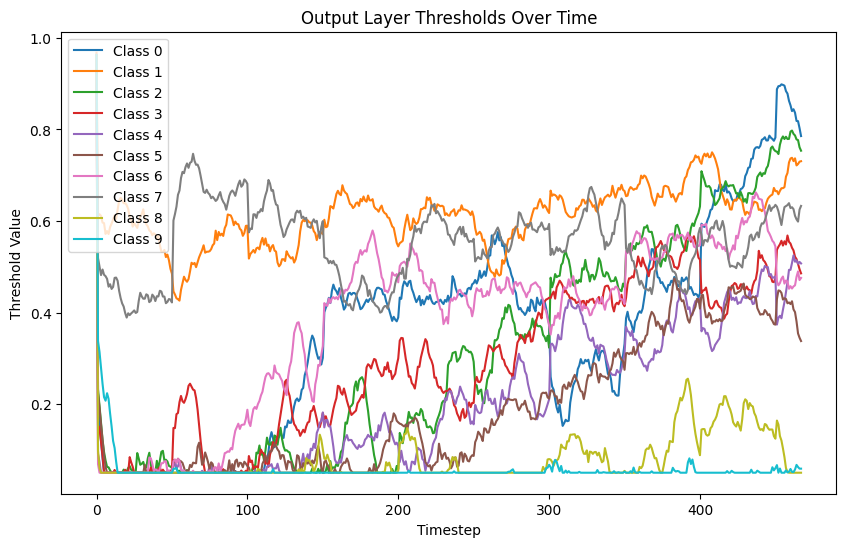

In [15]:
output_thresh = torch.stack(threshold_log_output)  # [T, 10]
output_thresh = output_thresh.numpy()

plt.figure(figsize=(10, 6))

for class_id in range(output_thresh.shape[1]):
    plt.plot(output_thresh[:, class_id], label=f"Class {class_id}")

plt.title("Output Layer Thresholds Over Time")
plt.xlabel("Timestep")
plt.ylabel("Threshold Value")
plt.legend()
plt.show()


# Old notes

The **resting membrane potential** is fixed to 0.0.

---

The **leak factor** of the membrane (beta) can be defined manually in the range [0,1], typically one chooses `beta=0.9`. A high beta refers to slow decay / long memory. A low beta refers to fast decay / short memory. It can be made learnable with `learn_beta=True`.

---

The **firing threshold** can be defined manually, typically one chooses `threshold=1.0`. It can be made learnable with `learn_threshold=True`.

---

For a **hard reset** use `reset_mechanism = “zero” `, which sets the membrane potential to 0.0 after a spike. <br>
For a **soft reset** use `reset_mechanism="subtract"`, which subtracts the firing threshold from the current membrane potential after a spike.

---

You can train the neuron via backpropagation. `spike_grad` is the **surrogate gradient function** used during backpropagation. By default it is `None`, i.e. the default is used. <br>
Examples for surrogate gradient functions are:
- `snntorch.surrogate.fast_sigmoid()`
- `snntorch.surrogate.atan()`
- `snntorch.surrogate.sigmoid()`

Surrogate gradients can also be **disabled** with `surrogate_disable=True` (per default, it is False). This makes the neuron non-trainable with gradient descent.

Construct a single 3-layer SNN architecture:
- **input layer [784 neurons]**: 1 neuron per img pixel (MNIST images are 28x28 pixels)
- **hidden layer [1000 neurons]**
- **output layer [10 neurons]**: 1 neuron per MNIST class

---

We have three options for encoding:

*   ***firing rate***: <br>
= we consider the firing rate of neurons <br>
--> use **rate encoding**: pixel intensities translate into a firing rate (high intensity = frequent spikes) <br>
--> the predicted class is determined based on **the output neuron that has highest spike count** <br>
--> in case of a smaller firing threshold, the **neuron would fire more frequently**

*   ***relative spike timing***: <br>
= we consider the firing time of neurons <br>
--> use **time-to-first spike encoding (TTFS)**: each neuron fires exactly once & pixel intensities are inversely proportional to their firing time (high intensity = early spike) <br>
--> the predicted class is determined based on **the output neuron that fires most quickly** <br>
--> in case of a smaller firing threshold, the **neuron would fire earlier**

*   ***rank order***: <br>
= we only care about the spike order of neurons, not their exact firing time <br>
--> use **rank order encoding**: each neuron fires exactly once & more intense pixels fire earlier <br>
--> the predicted class is determined based on **the output neuron that fires first** <br>
--> in case of a smaller firing threshold, the **neuron would fire earlier**

---

We run the same SNN under different HIP regimes:

#### **No Intrinsic Plasticity / Fixed threshold (Baseline)**
With a fixed firing threshold, the **neuron's activity depends on the input current**. <br>
For the input layer neurons in the SNN this means, the firing rate encodes input intensity: If an input neuron receives a high input current (pixel with high intensity), then its firing rate is high. If an input neuron receives a low input current (pixel with low intensity), then its firing rate is low. <br>

[Expectation]: The network tends to develop ...
- dead/silent neurons
- overactive neurons
- highly uneven activity distributions

#### **Global HIP**
All SNN neurons have the same target firing rate (We might want to try out different target firing rates such as high, medium, low.) <br>
[Expectation]: ???

#### **Layer-specific HIP**
Define a different target firing rate for each layer. (e.g. Input layer is high, hidden layer is medium, output layer is low) --> mimick biology, i.e. retina/LGN neurons fire a lot (input), primary visual cortex fire less / they become selective (e.g. orientation), higher cortex / decision areas fire very sparsely (clear decisions).
--> decreasing-activity hierarchy in the visual system: neural firing rates tend to drop as signals move from early sensory input areas to higher processing stages

Early visual areas (e.g., V1): Many neurons respond to relatively simple features such as edges, orientation, spatial frequency, and contrast. A visual stimulus can therefore activate many neurons.

Higher visual areas: Neurons tend to respond to more complex and abstract features, such as objects, faces, or semantic categories. Responses can become more selective/sparse—fewer neurons may respond strongly to a particular stimulus.

Evaluation measures
- Classification performance: accuracy of the model on test dataset
- Firing rate distribution per layer (histograms)
- Sparsity (fraction of active neurons per image)
- Stability over time (do neurons blow up or go silent?)
